# 🎮 Personalized VALORANT Match Analysis and Agent Recommendation System

## Notebook 01 — Exploratory Data Analysis

### Project Objective

The objective of this project is to develop a personalized VALORANT agent
recommendation system that learns from an individual player's historical
Competitive match data.

This notebook analyzes **Dev's VALORANT Competitive match history** in order to
understand his gameplay patterns across different agents and maps.

The final system takes a known map as input and generates **role-aware
personalized recommendations**, returning up to **two candidate agents per role**
based on historical agent performance, map experience, Agent × Map performance,
recent form, role history, and agent familiarity.

This notebook focuses on **Exploratory Data Analysis (EDA)** of Dev's Competitive
match-history dataset.

### Current Dataset

- Game Mode: Competitive
- Total Matches: 1080
- Data Period: June 2025 to September 2026
- Dataset Source: Dev's personal VALORANT match history
- Data Type: Tabular
- Total Original Features: 22

### Goals of This Notebook

1. Inspect the structure and quality of the dataset.
2. Identify missing values and duplicate records.
3. Study the distribution of wins, losses, and draws.
4. Analyze how frequently different agents and maps are played.
5. Examine overall player-performance statistics.
6. Compare performance across agents and maps.
7. Explore Agent × Map combinations.
8. Investigate relationships between match statistics and outcomes.
9. Detect unusual values and non-standard match scores.
10. Identify historical variables that may later be transformed into
    pre-match machine-learning features.

### Future Goal

The final recommendation system will use only information available before a
target match begins.

Historical features such as recent form, previous agent performance, previous
map performance, Agent × Map experience, and agent familiarity will be used to
rank the player's most suitable agents for a given map.

Different players may therefore receive different recommendations for the same
map because their gameplay histories and agent preferences are different.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_PATH = Path("../data/competitive_matches_dev.xlsx")

df = pd.read_excel(
    DATA_PATH,
    sheet_name="Matches",
    header=2,
    usecols="A:V"
)

df.head()

,Match id,Date,Map,Placement,Agent,Team Score,Opponent Score,Result,Win Flag,Score Margin,...,Deaths,Assists,K/D,Kills/Round,Deaths/Round,Assists/Round,DDΔ (Average Damage Delta per Round),HS% (Headshot Percentage),ACS (Average Combat Score),TRS (Tracker Score)
0,1,2025-06-21,Pearl,6th,Iso,10,13,Loss,0,-3,...,17,4,0.764706,0.565217,0.739130,0.173913,-25,0.24,174,274
1,2,2025-06-21,Icebox,7th,Neon,13,6,Win,1,7,...,15,3,0.933333,0.736842,0.789474,0.157895,-7,0.31,200,543
2,3,2025-06-22,Lotus,6th,Neon,8,13,Loss,0,-5,...,20,4,0.7,0.666667,0.952381,0.190476,-34,0.31,198,371
3,4,2025-06-22,Ascent,10th,Killjoy,6,13,Loss,0,-7,...,17,2,0.352941,0.315789,0.894737,0.105263,-71,0.17,115,126
4,5,2025-06-22,Icebox,2nd,Skye,4,0,Win,1,4,...,1,0,4,1.000000,0.250000,0.000000,72,0.40,230,886


In [3]:
df = df.rename(columns={
    "DDΔ (Average Damage Delta per Round)": "DDΔ",
    "HS% (Headshot Percentage)": "HS%",
    "ACS (Average Combat Score)": "ACS",
    "TRS (Tracker Score)": "TRS"
})

In [4]:
import numpy as np

df["K/D"] = df["K/D"].replace(
    ["N/A", "n/a", "NA", "-", ""],
    np.nan
)

df["K/D"] = pd.to_numeric(
    df["K/D"],
    errors="coerce"
)

df.loc[df["Result"] == "Draw", "Win Flag"] = np.nan

kd_values = pd.to_numeric(
    df["K/D"],
    errors="coerce"
).dropna()

In [5]:
print("Number of matches:", df.shape[0])
print("Number of features:", df.shape[1])

print("\nColumns:\n")
for column in df.columns:
    print(column)

Number of matches: 1080
Number of features: 22

Columns:

Match id
Date
Map
Placement
Agent
Team Score
Opponent Score
Result
Win Flag
Score Margin
Rounds Played
Kills
Deaths
Assists
K/D
Kills/Round
Deaths/Round
Assists/Round
DDΔ
HS%
ACS
TRS


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Match id        1080 non-null   int64         
 1   Date            1080 non-null   datetime64[us]
 2   Map             1080 non-null   str           
 3   Placement       1080 non-null   str           
 4   Agent           1080 non-null   str           
 5   Team Score      1080 non-null   int64         
 6   Opponent Score  1080 non-null   int64         
 7   Result          1080 non-null   str           
 8   Win Flag        1055 non-null   float64       
 9   Score Margin    1080 non-null   int64         
 10  Rounds Played   1080 non-null   int64         
 11  Kills           1080 non-null   int64         
 12  Deaths          1080 non-null   int64         
 13  Assists         1080 non-null   int64         
 14  K/D             1079 non-null   float64       
 15  Kills/Round    

In [7]:
df.isnull().sum()

Match id           0
Date               0
Map                0
Placement          0
Agent              0
Team Score         0
Opponent Score     0
Result             0
Win Flag          25
Score Margin       0
Rounds Played      0
Kills              0
Deaths             0
Assists            0
K/D                1
Kills/Round        0
Deaths/Round       0
Assists/Round      0
DDΔ                0
HS%                0
ACS                0
TRS                0
dtype: int64

In [8]:
print("Duplicate rows:", df.duplicated().sum())

print(
    "Duplicate Match id values:",
    df["Match id"].duplicated().sum()
)

Duplicate rows: 0
Duplicate Match id values: 0


In [9]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

print(
    "Oldest match:",
    df["Date"].min()
)

print(
    "Newest match:",
    df["Date"].max()
)

datetime64[us]
Oldest match: 2025-06-21 00:00:00
Newest match: 2026-09-19 00:00:00


In [10]:
print("========================")
print("Maps:")
print(df["Map"].value_counts())
print("========================")
print("\nAgents:")
print(df["Agent"].value_counts())
print("========================")
print("\nResults:")
print(df["Result"].value_counts())

Maps:
Map
Haven       157
Lotus       125
Split       105
Ascent      104
Bind         94
Breeze       93
Pearl        84
Corrode      84
Sunset       83
Abyss        62
Fracture     44
Icebox       23
Summit       22
Name: count, dtype: int64

Agents:
Agent
Neon         739
Chamber       55
Reyna         55
Astra         45
Jett          45
Omen          20
Clove         18
Phoenix       16
Iso           15
Yoru          10
Breach         9
Gekko          9
Brimstone      8
Sage           7
Miks           6
Skye           4
Raze           4
Cypher         3
Sova           3
Deadlock       2
Tejo           2
Killjoy        1
Waylay         1
Vyse           1
Viper          1
Fade           1
Name: count, dtype: int64

Results:
Result
Loss    540
Win     515
Draw     25
Name: count, dtype: int64


In [11]:
result_counts = df["Result"].value_counts()

print(result_counts)

Result
Loss    540
Win     515
Draw     25
Name: count, dtype: int64


In [12]:
result_percentages = (
    df["Result"]
    .value_counts(normalize=True)
    * 100
)

print(result_percentages.round(2))

Result
Loss    50.00
Win     47.69
Draw     2.31
Name: proportion, dtype: float64


In [13]:
df.describe()

,Match id,Date,Team Score,Opponent Score,Win Flag,Score Margin,Rounds Played,Kills,Deaths,Assists,K/D,Kills/Round,Deaths/Round,Assists/Round,DDΔ,HS%,ACS,TRS
count,1080.00000,1080,1080.000000,1080.000000,1055.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1079.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000
mean,540.50000,2026-02-08 13:32:00,10.445370,10.589815,0.488152,-0.144444,21.035185,17.452778,16.413889,3.355556,1.112570,0.830682,0.779277,0.159250,2.726852,0.261611,234.629630,549.740741
min,1.00000,2025-06-21 00:00:00,0.000000,0.000000,0.000000,-13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-134.000000,0.000000,0.000000,100.000000
25%,270.75000,2025-09-27 00:00:00,8.000000,8.000000,0.000000,-5.000000,19.000000,13.000000,14.000000,2.000000,0.777778,0.649265,0.714286,0.090909,-32.000000,0.200000,185.000000,361.000000
50%,540.50000,2026-02-20 00:00:00,13.000000,13.000000,0.000000,-1.000000,21.000000,17.000000,17.000000,3.000000,1.047619,0.818182,0.782609,0.142857,-1.000000,0.250000,230.000000,557.000000
75%,810.25000,2026-05-26 00:00:00,13.000000,13.000000,1.000000,5.000000,23.000000,22.000000,19.000000,5.000000,1.368421,1.000000,0.863636,0.217731,34.000000,0.310000,280.000000,744.000000
max,1080.00000,2026-09-19 00:00:00,17.000000,17.000000,1.000000,13.000000,32.000000,42.000000,28.000000,24.000000,4.714286,1.888889,1.133333,1.043478,195.000000,0.640000,535.000000,1000.000000
std,311.91345,NaN,3.498547,3.492517,0.500097,5.866879,3.801939,6.474702,3.784755,2.264991,0.499596,0.277533,0.124463,0.104410,50.638888,0.088684,73.771105,241.984178


In [14]:
print(df.columns.tolist())

['Match id', 'Date', 'Map', 'Placement', 'Agent', 'Team Score', 'Opponent Score', 'Result', 'Win Flag', 'Score Margin', 'Rounds Played', 'Kills', 'Deaths', 'Assists', 'K/D', 'Kills/Round', 'Deaths/Round', 'Assists/Round', 'DDΔ', 'HS%', 'ACS', 'TRS']


In [15]:
total_matches = len(df)

wins = (df["Result"] == "Win").sum()
losses = (df["Result"] == "Loss").sum()
draws = (df["Result"] == "Draw").sum()

win_rate = wins / total_matches

total_kills = df["Kills"].sum()
total_deaths = df["Deaths"].sum()

overall_kd = total_kills / total_deaths

average_acs = df["ACS"].mean()
average_hs = df["HS%"].mean()

print("=== OVERALL PERFORMANCE ===")

print(f"Matches: {total_matches}")
print(f"Wins: {wins}")
print(f"Losses: {losses}")
print(f"Draws: {draws}")

print(f"Win Rate: {win_rate:.2%}")
print(f"Overall K/D: {overall_kd:.2f}")
print(f"Average ACS: {average_acs:.2f}")
print(f"Average HS%: {average_hs:.2%}")

=== OVERALL PERFORMANCE ===
Matches: 1080
Wins: 515
Losses: 540
Draws: 25
Win Rate: 47.69%
Overall K/D: 1.06
Average ACS: 234.63
Average HS%: 26.16%


**WIN VS LOSS VS DRAW**


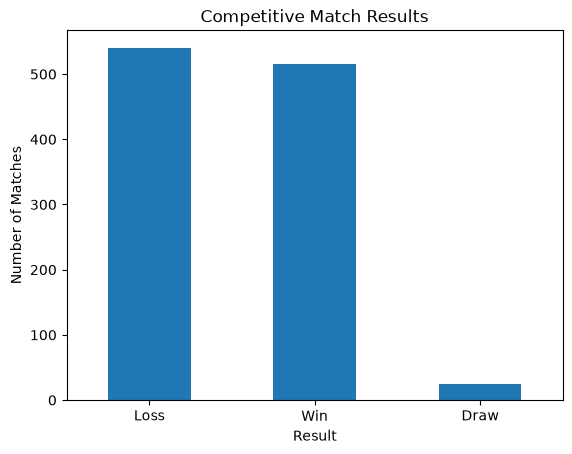

In [16]:
df["Result"].value_counts().plot(
    kind="bar",
    title="Competitive Match Results"
)

plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)

plt.show()

**MATCHES PLAYED BY AGENTS**


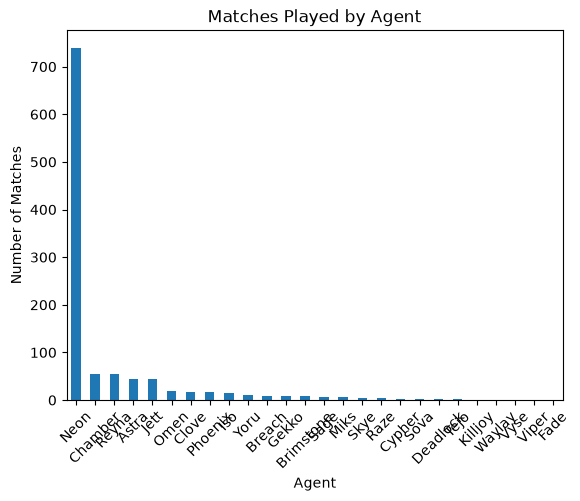

In [17]:
df["Agent"].value_counts().plot(
    kind="bar",
    title="Matches Played by Agent"
)

plt.xlabel("Agent")
plt.ylabel("Number of Matches")

plt.xticks(
    rotation=45
)

plt.show()

**MATCHES PLAYED ON MAPS**


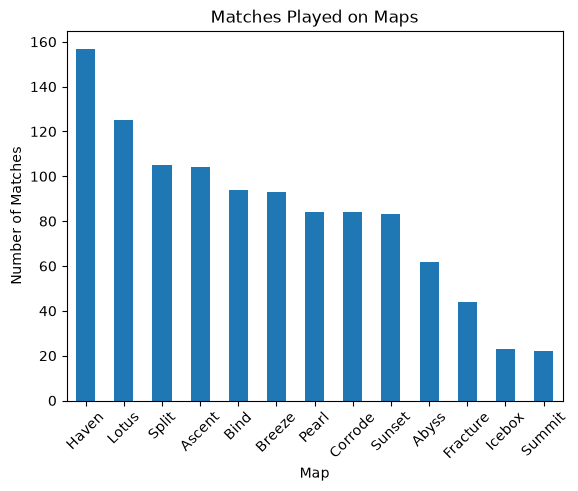

In [18]:
df["Map"].value_counts().plot(
    kind="bar",
    title="Matches Played on Maps"
)

plt.xlabel("Map")
plt.ylabel("Number of Matches")

plt.xticks(
    rotation=45
)

plt.show()

## Performance by Agent

This section compares Dev's historical Competitive performance across the
different agents he has played.

Metrics such as number of matches, historical win rate, overall K/D, ACS,
headshot percentage, and damage delta are used to identify differences in
performance across agents.

The dataset is strongly dominated by **Neon**, so sample size must be considered
when comparing frequently played agents with agents that have only a small
number of matches.

This analysis is important for the final recommendation system because agent
familiarity and previous experience contribute to the historical profile used
to score candidate agents.


In [19]:
agent_stats = (
    df.groupby("Agent")
    .agg(
        Matches=("Match id", "count"),
        Wins=("Win Flag", "sum"),
        Kills=("Kills", "sum"),
        Deaths=("Deaths", "sum"),
        Assists=("Assists", "sum"),
        Avg_ACS=("ACS", "mean"),
        Avg_HS=("HS%", "mean"),
        Avg_DD=("DDΔ", "mean")
    )
)

agent_stats["Win_Rate"] = (
    agent_stats["Wins"] / agent_stats["Matches"]
)

agent_stats["Overall_KD"] = (
    agent_stats["Kills"] / agent_stats["Deaths"]
)

agent_stats.sort_values(
    "Matches",
    ascending=False
).round(2)

,Matches,Wins,Kills,Deaths,Assists,Avg_ACS,Avg_HS,Avg_DD,Win_Rate,Overall_KD
Agent,,,,,,,,,,
Neon,739,362.0,13122,12160,2282,239.84,0.25,4.28,0.49,1.08
Chamber,55,29.0,982,860,142,232.58,0.30,12.51,0.53,1.14
Reyna,55,27.0,979,891,207,230.25,0.28,1.73,0.49,1.10
Jett,45,21.0,776,748,150,235.96,0.29,4.42,0.47,1.04
Astra,45,23.0,736,666,214,225.42,0.31,12.42,0.51,1.11
Omen,20,7.0,332,351,85,210.65,0.30,-10.15,0.35,0.95
Clove,18,9.0,298,336,83,224.89,0.35,-18.83,0.50,0.89
Phoenix,16,6.0,249,266,56,207.06,0.28,-32.62,0.38,0.94
Iso,15,5.0,287,272,45,239.33,0.33,9.40,0.33,1.06


## Performance by Map

This section compares Dev's historical Competitive performance across different
VALORANT maps.

Metrics such as number of matches, historical win rate, overall K/D, ACS,
headshot percentage, and damage delta are used to identify map-specific
performance patterns.

Map performance is important for the final recommendation system because the
same player may perform differently depending on the map being played.

The number of matches played on each map must also be considered when
interpreting win rates, because maps with smaller sample sizes may show unstable
or exaggerated performance values.


In [20]:
map_stats = (
    df.groupby("Map")
    .agg(
        Matches=("Match id", "count"),
        Wins=("Win Flag", "sum"),
        Kills=("Kills", "sum"),
        Deaths=("Deaths", "sum"),
        Assists=("Assists", "sum"),
        Avg_ACS=("ACS", "mean"),
        Avg_HS=("HS%", "mean"),
        Avg_DD=("DDΔ", "mean")
    )
)

map_stats["Win_Rate"] = (
    map_stats["Wins"] / map_stats["Matches"]
)

map_stats["Overall_KD"] = (
    map_stats["Kills"] / map_stats["Deaths"]
)

map_stats.sort_values(
    "Matches",
    ascending=False
).round(2)

,Matches,Wins,Kills,Deaths,Assists,Avg_ACS,Avg_HS,Avg_DD,Win_Rate,Overall_KD
Map,,,,,,,,,,
Haven,157,62.0,2728,2597,461,232.68,0.26,0.32,0.39,1.05
Lotus,125,58.0,2103,2027,418,227.49,0.27,0.87,0.46,1.04
Split,105,49.0,1903,1726,375,244.58,0.27,5.34,0.47,1.10
Ascent,104,47.0,1747,1711,378,228.33,0.26,-2.30,0.45,1.02
Bind,94,50.0,1737,1577,324,245.66,0.24,6.81,0.53,1.10
Breeze,93,43.0,1720,1503,320,245.26,0.27,12.05,0.46,1.14
Corrode,84,36.0,1467,1386,271,234.83,0.25,0.83,0.43,1.06
Pearl,84,42.0,1380,1391,284,220.86,0.26,-4.50,0.50,0.99
Sunset,83,48.0,1529,1347,276,243.61,0.28,12.66,0.58,1.14


## Agent × Map Analysis

This section analyzes Dev's performance for specific Agent × Map combinations.

The objective is to determine whether his performance changes depending on
which agent is selected on a particular map.

This interaction is especially important for the final recommendation system,
because the model should not evaluate an agent independently from the map.

For example, Dev may have strong overall performance with an agent but weaker
historical results with that same agent on a particular map.

Because some Agent × Map combinations contain only a small number of matches,
sample size must be considered before interpreting their win rates and
performance statistics.


In [21]:
agent_map_stats = (
    df.groupby(["Map", "Agent"])
    .agg(
        Matches=("Match id", "count"),
        Wins=("Win Flag", "sum"),
        Kills=("Kills", "sum"),
        Deaths=("Deaths", "sum"),
        Assists=("Assists", "sum"),
        Avg_ACS=("ACS", "mean"),
        Avg_HS=("HS%", "mean"),
        Avg_DD=("DDΔ", "mean")
    )
    .reset_index()
)

agent_map_stats["Win_Rate"] = (
    agent_map_stats["Wins"] / agent_map_stats["Matches"]
)

agent_map_stats["Overall_KD"] = (
    agent_map_stats["Kills"] / agent_map_stats["Deaths"]
)

agent_map_stats.sort_values(
    "Matches",
    ascending=False
).head(20).round(2)

,Map,Agent,Matches,Wins,Kills,Deaths,Assists,Avg_ACS,Avg_HS,Avg_DD,Win_Rate,Overall_KD
77,Haven,Neon,112,44.0,1952,1855,316,237.85,0.25,0.52,0.39,1.05
28,Bind,Neon,76,41.0,1455,1281,246,255.39,0.23,10.50,0.54,1.14
126,Split,Neon,76,34.0,1435,1267,255,253.36,0.25,8.59,0.45,1.13
98,Lotus,Neon,72,34.0,1207,1184,241,225.85,0.25,-0.38,0.47,1.02
17,Ascent,Neon,65,29.0,1119,1061,224,236.66,0.24,5.62,0.45,1.05
114,Pearl,Neon,60,33.0,1001,1006,188,223.22,0.24,-4.23,0.55,1.00
42,Breeze,Neon,60,31.0,1114,946,178,246.77,0.25,12.10,0.52,1.18
55,Corrode,Neon,58,26.0,1010,943,161,240.60,0.25,0.33,0.45,1.07
143,Sunset,Neon,55,32.0,1037,890,165,252.45,0.26,15.76,0.58,1.17
5,Abyss,Neon,43,19.0,732,696,113,235.49,0.23,2.72,0.44,1.05


## K/D Distribution

This section examines the distribution of Dev's K/D ratios across all
Competitive matches.

The purpose is to understand his typical K/D range, identify unusually high or
low performances, and observe how combat performance varies across the dataset.

One match contains an undefined K/D value because the player recorded zero
deaths. This value is treated as missing rather than assigning an artificial
numerical ratio.


In [22]:
print(df["K/D"].dtype)

float64


In [23]:
bad_kd = pd.to_numeric(
    df["K/D"],
    errors="coerce"
).isna() & df["K/D"].notna()

df.loc[bad_kd, ["Match id", "K/D"]]

,Match id,K/D


In [24]:
import numpy as np
import pandas as pd

df["K/D"] = df["K/D"].replace(
    ["N/A", "n/a", "NA", "-", ""],
    np.nan
)

df["K/D"] = pd.to_numeric(
    df["K/D"],
    errors="coerce"
)

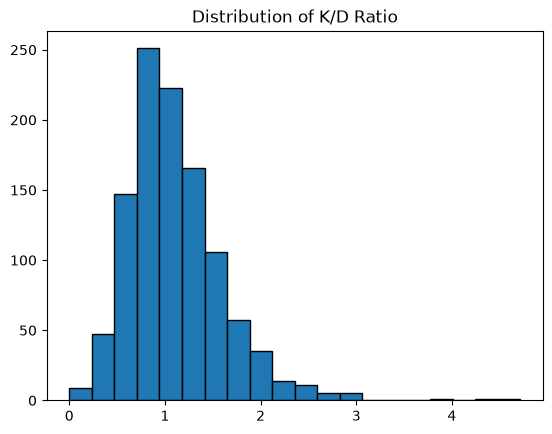

In [25]:
plt.hist(
    kd_values,
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of K/D Ratio")

plt.show()

In [26]:
print("Average K/D:", round(df["K/D"].mean(), 2))
print("Median K/D:", round(df["K/D"].median(), 2))
print("Minimum K/D:", round(df["K/D"].min(), 2))
print("Maximum K/D:", round(df["K/D"].max(), 2))

Average K/D: 1.11
Median K/D: 1.05
Minimum K/D: 0.0
Maximum K/D: 4.71


## ACS Distribution

This section examines the distribution of Dev's Average Combat Score (ACS)
across all Competitive matches.

The goal is to understand his typical ACS range, identify unusually strong or
weak combat performances, and observe how overall combat contribution is
distributed across the dataset.

ACS is used here for descriptive analysis and may later contribute to historical
rolling features, but the ACS from the target match itself cannot be used for
pre-match prediction.


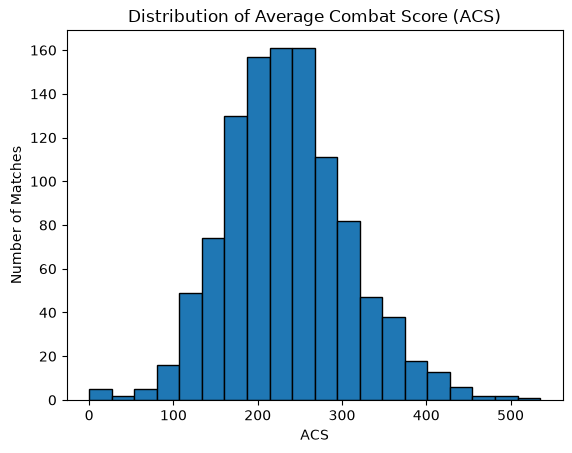

In [27]:
plt.hist(
    df["ACS"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Average Combat Score (ACS)")
plt.xlabel("ACS")
plt.ylabel("Number of Matches")

plt.show()

In [28]:
print("Average ACS:", round(df["ACS"].mean(), 2))
print("Median ACS:", round(df["ACS"].median(), 2))
print("Minimum ACS:", df["ACS"].min())
print("Maximum ACS:", df["ACS"].max())

Average ACS: 234.63
Median ACS: 230.0
Minimum ACS: 0
Maximum ACS: 535


## DDΔ Distribution

This section examines the distribution of Dev's Average Damage Delta per Round
(DDΔ) across all Competitive matches.

DDΔ represents the difference between damage dealt and damage received per
round.

Positive DDΔ values indicate that more damage was dealt than received, while
negative values indicate that more damage was received than dealt.

The distribution helps identify Dev's typical damage efficiency as well as
unusually strong or weak matches.

Current-match DDΔ is a post-match variable and will therefore only be used for
EDA or for constructing historical features from earlier matches.


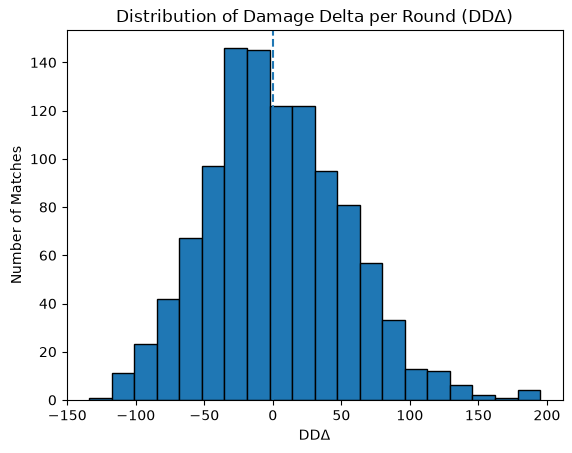

In [29]:
plt.hist(
    df["DDΔ"],
    bins=20,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution of Damage Delta per Round (DDΔ)")
plt.xlabel("DDΔ")
plt.ylabel("Number of Matches")

plt.show()

In [30]:
print("Average DDΔ:", round(df["DDΔ"].mean(), 2))
print("Median DDΔ:", round(df["DDΔ"].median(), 2))
print("Minimum DDΔ:", df["DDΔ"].min())
print("Maximum DDΔ:", df["DDΔ"].max())

Average DDΔ: 2.73
Median DDΔ: -1.0
Minimum DDΔ: -134
Maximum DDΔ: 195


## Wins vs Losses Comparison

This section compares Dev's performance metrics across matches that were won,
lost, or drawn.

The purpose is to identify which performance statistics tend to differ between
different match outcomes.

During the **initial EDA of the original dataset**, metrics such as K/D, ACS,
DDΔ, kills, deaths, assists, and TRS were compared descriptively. `TRS` was
later removed from the revised dataset and is not used in the final model.

These relationships show association with match outcomes but do not necessarily
imply causation.

Because the final recommendation system must operate before a match begins,
current-match performance statistics will not be used directly as predictive
features.


In [31]:
result_performance = (
    df.groupby("Result")
    .agg(
        Avg_KD=("K/D", "mean"),
        Avg_ACS=("ACS", "mean"),
        Avg_DD=("DDΔ", "mean"),
        Avg_Kills=("Kills", "mean"),
        Avg_Deaths=("Deaths", "mean"),
        Avg_Assists=("Assists", "mean"),
        Avg_TRS=("TRS", "mean")
    )
)

result_performance.round(2)

,Avg_KD,Avg_ACS,Avg_DD,Avg_Kills,Avg_Deaths,Avg_Assists,Avg_TRS
Result,,,,,,,
Draw,1.13,250.04,14.68,21.84,20.32,4.60,594.08
Loss,0.90,213.72,-17.26,15.66,17.34,3.13,417.69
Win,1.33,255.81,23.11,19.12,15.26,3.53,686.05


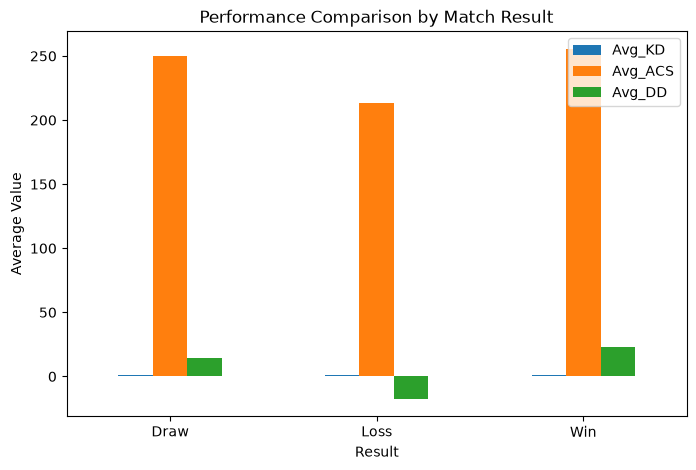

In [32]:
result_performance[
    ["Avg_KD", "Avg_ACS", "Avg_DD"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Performance Comparison by Match Result")
plt.xlabel("Result")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.show()

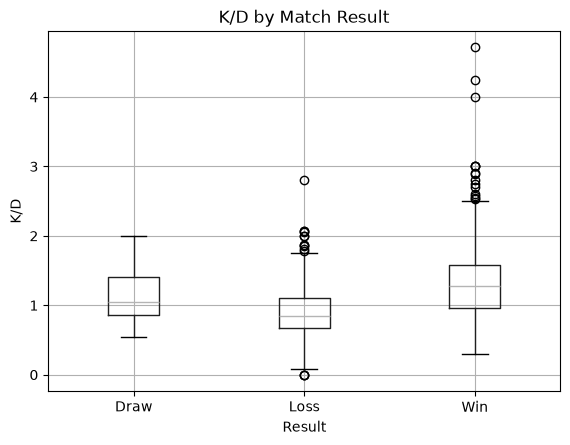

In [33]:
df.boxplot(
    column="K/D",
    by="Result"
)

plt.title("K/D by Match Result")
plt.suptitle("")
plt.xlabel("Result")
plt.ylabel("K/D")

plt.show()

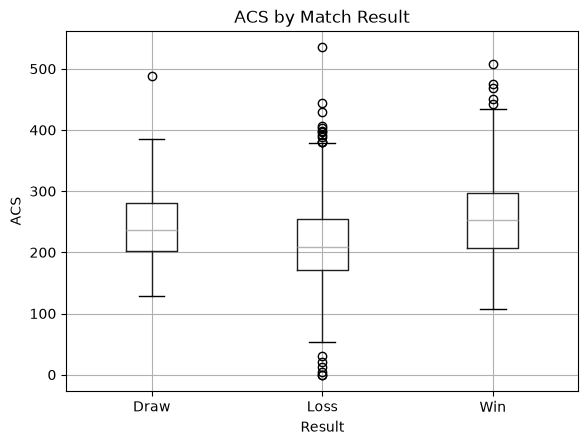

In [34]:
df.boxplot(
    column="ACS",
    by="Result"
)

plt.title("ACS by Match Result")
plt.suptitle("")
plt.xlabel("Result")
plt.ylabel("ACS")

plt.show()

## Correlation Analysis

This section examines relationships between numerical features in Dev's
Competitive match dataset.

Correlation values range from -1 to +1:

- Values close to +1 indicate a strong positive linear relationship.
- Values close to -1 indicate a strong negative linear relationship.
- Values close to 0 indicate little or no linear relationship.

Special attention is given to correlations with `Win Flag` in order to identify
which match-performance variables are associated with wins and losses.

These correlations are useful for understanding the original dataset. `TRS` was
later removed from the revised role-aware dataset. Current-match statistics such
as K/D, ACS, DDΔ, kills, and deaths are not valid pre-match features because they
are only known after or during the target match.

Correlation does not imply causation.


In [35]:
numeric_columns = [
    "Win Flag",
    "Kills",
    "Deaths",
    "Assists",
    "K/D",
    "Kills/Round",
    "Deaths/Round",
    "Assists/Round",
    "DDΔ",
    "HS%",
    "ACS",
    "TRS"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix.round(2)

,Win Flag,Kills,Deaths,Assists,K/D,Kills/Round,Deaths/Round,Assists/Round,DDΔ,HS%,ACS,TRS
Win Flag,1.00,0.27,-0.28,0.09,0.43,0.34,-0.43,0.10,0.40,0.10,0.29,0.55
Kills,0.27,1.00,0.22,0.13,0.71,0.85,-0.22,-0.00,0.75,0.15,0.84,0.76
Deaths,-0.28,0.22,1.00,0.24,-0.43,-0.20,0.65,0.02,-0.36,-0.07,-0.14,-0.26
Assists,0.09,0.13,0.24,1.00,-0.03,-0.01,0.03,0.94,0.06,-0.10,0.06,0.16
K/D,0.43,0.71,-0.43,-0.03,1.00,0.90,-0.61,0.01,0.90,0.19,0.85,0.85
Kills/Round,0.34,0.85,-0.20,-0.01,0.90,1.00,-0.31,0.00,0.89,0.19,0.98,0.88
Deaths/Round,-0.43,-0.22,0.65,0.03,-0.61,-0.31,1.00,0.01,-0.56,-0.07,-0.24,-0.47
Assists/Round,0.10,-0.00,0.02,0.94,0.01,0.00,0.01,1.00,0.10,-0.09,0.08,0.17
DDΔ,0.40,0.75,-0.36,0.06,0.90,0.89,-0.56,0.10,1.00,0.19,0.89,0.90
HS%,0.10,0.15,-0.07,-0.10,0.19,0.19,-0.07,-0.09,0.19,1.00,0.16,0.16


In [36]:
win_correlations = (
    correlation_matrix["Win Flag"]
    .drop("Win Flag")
    .sort_values(ascending=False)
)

win_correlations.round(2)

TRS              0.55
K/D              0.43
DDΔ              0.40
Kills/Round      0.34
ACS              0.29
Kills            0.27
Assists/Round    0.10
HS%              0.10
Assists          0.09
Deaths          -0.28
Deaths/Round    -0.43
Name: Win Flag, dtype: float64

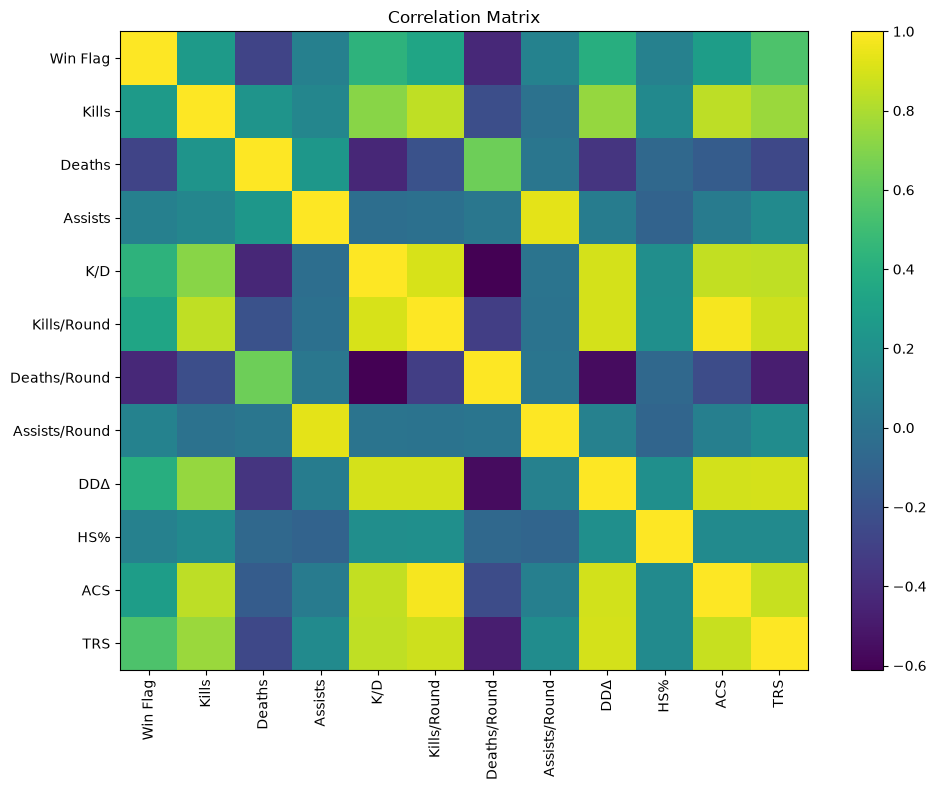

In [37]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(numeric_columns)),
    numeric_columns,
    rotation=90
)

plt.yticks(
    range(len(numeric_columns)),
    numeric_columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## Outlier Analysis

This section investigates unusually high or low values in important performance
metrics such as K/D, ACS, and DDΔ.

Outliers are examined to determine whether they represent valid extreme
performances or possible data-quality issues.

Because gaming performance naturally varies from match to match, an extreme
value is not automatically considered incorrect.

Outliers are therefore retained unless there is evidence that the underlying
match record is invalid.


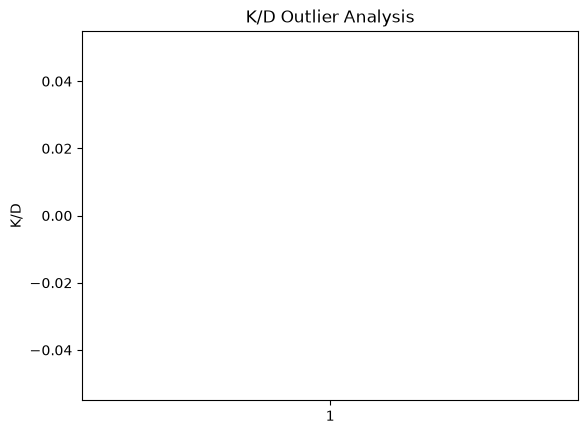

In [38]:
plt.boxplot(df["K/D"])

plt.title("K/D Outlier Analysis")
plt.ylabel("K/D")

plt.show()

Highest k/d matches


In [39]:
df.sort_values(
    "K/D",
    ascending=False
)[
    [
        "Date",
        "Map",
        "Agent",
        "Kills",
        "Deaths",
        "K/D",
        "ACS",
        "DDΔ"
    ]
].head(10)

,Date,Map,Agent,Kills,Deaths,K/D,ACS,DDΔ
576,2026-03-14,Corrode,Neon,33,7,4.714286,421,166
959,2026-07-04,Lotus,Neon,34,8,4.250000,508,183
4,2025-06-22,Icebox,Skye,4,1,4.000000,230,72
551,2026-03-03,Abyss,Neon,24,8,3.000000,434,128
778,2026-05-22,Lotus,Reyna,12,4,3.000000,243,56
866,2026-06-14,Fracture,Neon,24,8,3.000000,361,127
744,2026-05-16,Split,Yoru,29,10,2.900000,405,136
164,2025-08-23,Sunset,Neon,26,9,2.888889,427,146
552,2026-03-03,Split,Neon,42,15,2.800000,468,157
902,2026-06-25,Haven,Neon,42,15,2.800000,535,191


Lowest k/d matches


In [40]:
df.sort_values(
    "K/D",
    ascending=True
)[
    [
        "Date",
        "Map",
        "Agent",
        "Kills",
        "Deaths",
        "K/D",
        "ACS",
        "DDΔ"
    ]
].head(10)

,Date,Map,Agent,Kills,Deaths,K/D,ACS,DDΔ
1024,2026-08-01,Lotus,Neon,0,1,0.000000,0,-9
822,2026-06-03,Haven,Astra,0,1,0.000000,0,-5
800,2026-05-25,Haven,Jett,0,10,0.000000,5,-98
927,2026-06-29,Split,Brimstone,1,13,0.076923,20,-134
473,2026-01-27,Haven,Neon,3,15,0.200000,58,-116
847,2026-06-10,Breeze,Reyna,3,14,0.214286,72,-111
216,2025-09-13,Ascent,Astra,3,14,0.214286,56,-103
322,2025-11-29,Sunset,Neon,3,14,0.214286,64,-111
537,2026-02-19,Breeze,Brimstone,4,17,0.235294,86,-107
272,2025-09-27,Bind,Astra,5,19,0.263158,99,-100


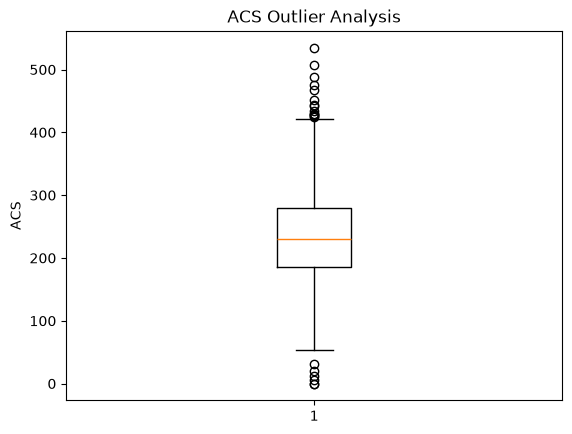

In [41]:
plt.boxplot(df["ACS"])

plt.title("ACS Outlier Analysis")
plt.ylabel("ACS")

plt.show()

In [42]:
df.sort_values(
    "ACS",
    ascending=False
)[
    [
        "Date",
        "Map",
        "Agent",
        "Kills",
        "Deaths",
        "K/D",
        "ACS",
        "DDΔ"
    ]
].head(10)

,Date,Map,Agent,Kills,Deaths,K/D,ACS,DDΔ
902,2026-06-25,Haven,Neon,42,15,2.800000,535,191
959,2026-07-04,Lotus,Neon,34,8,4.250000,508,183
1043,2026-08-16,Breeze,Astra,6,3,2.000000,488,195
638,2026-04-17,Breeze,Neon,38,15,2.533333,475,181
552,2026-03-03,Split,Neon,42,15,2.800000,468,157
534,2026-02-16,Abyss,Neon,40,16,2.500000,451,137
1060,2026-09-11,Summit,Clove,32,22,1.454545,444,90
278,2025-10-09,Sunset,Neon,33,13,2.538462,442,128
551,2026-03-03,Abyss,Neon,24,8,3.000000,434,128
558,2026-03-04,Abyss,Neon,36,14,2.571429,430,141


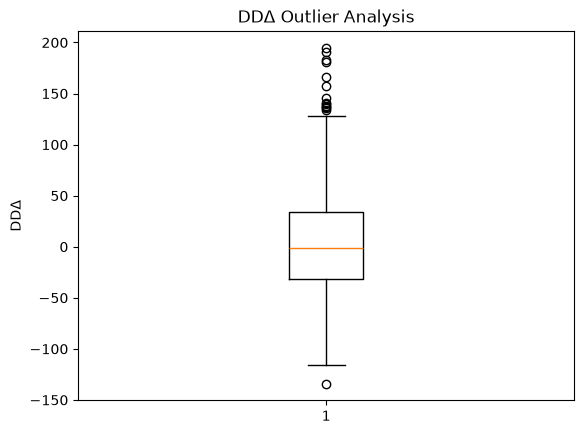

In [43]:
plt.boxplot(df["DDΔ"])

plt.title("DDΔ Outlier Analysis")
plt.ylabel("DDΔ")

plt.show()

In [44]:
df.sort_values(
    "DDΔ",
    ascending=False
)[
    [
        "Date",
        "Map",
        "Agent",
        "Kills",
        "Deaths",
        "K/D",
        "ACS",
        "DDΔ"
    ]
].head(10)

,Date,Map,Agent,Kills,Deaths,K/D,ACS,DDΔ
1043,2026-08-16,Breeze,Astra,6,3,2.000000,488,195
902,2026-06-25,Haven,Neon,42,15,2.800000,535,191
959,2026-07-04,Lotus,Neon,34,8,4.250000,508,183
638,2026-04-17,Breeze,Neon,38,15,2.533333,475,181
576,2026-03-14,Corrode,Neon,33,7,4.714286,421,166
552,2026-03-03,Split,Neon,42,15,2.800000,468,157
164,2025-08-23,Sunset,Neon,26,9,2.888889,427,146
558,2026-03-04,Abyss,Neon,36,14,2.571429,430,141
373,2025-12-25,Bind,Neon,26,10,2.600000,426,140
285,2025-10-14,Corrode,Neon,26,12,2.166667,414,138


## Match Score Validation and Match Ending Type

This section validates Competitive match scores and identifies how each match
ended.

Matches may end through:

- Regulation
- Overtime
- Overtime Draw
- Surrender
- Other unusual early-ending cases requiring manual review

Some matches therefore have final scores below the normal 13-round winning
threshold because one of the teams surrendered before the match was completed.

For surrendered matches, the recorded match result is used to determine which
side surrendered:

- `Result = Win` indicates that the opponent team surrendered.
- `Result = Loss` indicates that the player's team surrendered.

The final score alone cannot always identify which team surrendered because a
team may surrender even while the recorded round score is tied or while it is
leading.

Surrendered matches are valid Competitive observations and are retained in the
dataset.

Matches that do not match the expected Regulation, Overtime, Overtime Draw, or
Surrender patterns are flagged for manual review.


In [45]:
def classify_match_end(team_score, opponent_score, result):

    high = max(team_score, opponent_score)
    low = min(team_score, opponent_score)

    # Overtime Draw
    if result == "Draw":
        if team_score == opponent_score and team_score >= 13:
            return "Overtime Draw"

        return "Review"

    # Regulation ending
    if high == 13 and low <= 11:
        return "Regulation"

    # Overtime ending
    if high >= 14 and low >= 12 and (high - low) == 2:
        return "Overtime"

    # A Win/Loss with a non-standard final score
    # indicates that the match ended through surrender
    if result in ["Win", "Loss"]:
        return "Surrender"

    return "Review"

In [46]:
df["Match End Type"] = df.apply(
    lambda row: classify_match_end(
        row["Team Score"],
        row["Opponent Score"],
        row["Result"]
    ),
    axis=1
)

df["Match End Type"].value_counts()

Match End Type
Regulation       926
Overtime         113
Overtime Draw     23
Surrender         16
Review             2
Name: count, dtype: int64

In [47]:
def surrendered_by(row):

    if row["Match End Type"] != "Surrender":
        return None

    if row["Result"] == "Win":
        return "Opponent Team"

    if row["Result"] == "Loss":
        return "My Team"

    return "Unknown"


df["Surrendered By"] = df.apply(
    surrendered_by,
    axis=1
)

In [48]:
df["Surrendered By"].value_counts()

Surrendered By
Opponent Team    11
My Team           5
Name: count, dtype: int64

In [49]:
df[
    df["Match End Type"] == "Surrender"
][
    [
        "Match id",
        "Date",
        "Map",
        "Agent",
        "Team Score",
        "Opponent Score",
        "Result",
        "Surrendered By"
    ]
]

,Match id,Date,Map,Agent,Team Score,Opponent Score,Result,Surrendered By
4,5,2025-06-22,Icebox,Skye,4,0,Win,Opponent Team
147,148,2025-08-12,Corrode,Neon,8,4,Win,Opponent Team
281,282,2025-10-09,Sunset,Neon,9,7,Win,Opponent Team
377,378,2025-12-26,Sunset,Neon,7,2,Win,Opponent Team
405,406,2025-12-28,Haven,Reyna,8,3,Win,Opponent Team
463,464,2026-01-26,Haven,Neon,3,5,Loss,My Team
517,518,2026-02-10,Abyss,Neon,7,2,Win,Opponent Team
566,567,2026-03-05,Haven,Neon,4,0,Win,Opponent Team
625,626,2026-04-04,Pearl,Neon,5,3,Win,Opponent Team
634,635,2026-04-12,Breeze,Neon,4,0,Win,Opponent Team


In [50]:
# ============================================================
# LOAD UPDATED ROLE-AWARE DATASET
# ============================================================

UPDATED_DATA_PATH = Path(
    "../data/updated/competitive_matches_dev_role_updated.xlsx"
)

df_updated = pd.read_excel(
    UPDATED_DATA_PATH,
    sheet_name="Matches",
    header=2,
    usecols="A:V"
)


df_updated = df_updated.rename(
    columns={
        "DDΔ (Average Damage Delta per Round)": "DDΔ",
        "HS% (Headshot Percentage)": "HS%",
        "ACS (Average Combat Score)": "ACS"
    }
)


df_updated["Date"] = pd.to_datetime(
    df_updated["Date"]
)


df_updated["K/D"] = pd.to_numeric(
    df_updated["K/D"],
    errors="coerce"
)


df_updated["ACS"] = pd.to_numeric(
    df_updated["ACS"],
    errors="coerce"
)


df_updated.loc[
    df_updated["Result"] == "Draw",
    "Win Flag"
] = pd.NA


df_updated.head()

,Match id,Date,Map,Placement,Agent,Role,Team Score,Opponent Score,Result,Win Flag,...,Kills,Deaths,Assists,K/D,Kills/Round,Deaths/Round,Assists/Round,DDΔ,HS%,ACS
0,1,2025-06-21,Pearl,6th,Iso,Duelist,10,13,Loss,0.0,...,13,17,4,0.764706,0.565217,0.739130,0.173913,-25,0.24,174
1,2,2025-06-21,Icebox,7th,Neon,Duelist,13,6,Win,1.0,...,14,15,3,0.933333,0.736842,0.789474,0.157895,-7,0.31,200
2,3,2025-06-22,Lotus,6th,Neon,Duelist,8,13,Loss,0.0,...,14,20,4,0.700000,0.666667,0.952381,0.190476,-34,0.31,198
3,4,2025-06-22,Ascent,10th,Killjoy,Sentinel,6,13,Loss,0.0,...,6,17,2,0.352941,0.315789,0.894737,0.105263,-71,0.17,115
4,5,2025-06-22,Icebox,2nd,Skye,Initiator,4,0,Win,1.0,...,4,1,0,4.000000,1.000000,0.250000,0.000000,72,0.40,230


# Updated Dataset: Role-Aware EDA

Following feedback on the initial dataset design, the raw match-history dataset
was revised to better support a role-aware agent recommendation system.

The following changes were made:

- `TRS (Tracker Score)` was removed from the dataset.
- A new categorical feature, `Role`, was added immediately after `Agent`.
- Each agent is mapped to one of four VALORANT roles:
  - Duelist
  - Controller
  - Initiator
  - Sentinel
- ACS is retained as a performance measure.

The agent determines the official role, while ACS is used to study how strongly
the player performs when playing agents belonging to each role.

The purpose of this update is to prevent the final recommendation system from
returning several agents from the same role. The final recommendation layer
evaluates agents within their respective roles and can return up to **two
personalized candidate agents per role**.

The earlier EDA is retained because it still describes the original match
history correctly. The following cells specifically analyze the revised,
role-aware dataset.


In [51]:
# ============================================================
# LOAD UPDATED ROLE-AWARE DATASET
# ============================================================

UPDATED_DATA_PATH = Path(
    "../data/updated/competitive_matches_dev_role_updated.xlsx"
)

df_updated = pd.read_excel(
    UPDATED_DATA_PATH,
    sheet_name="Matches",
    header=2,
    usecols="A:V"
)


df_updated = df_updated.rename(
    columns={
        "DDΔ (Average Damage Delta per Round)": "DDΔ",
        "HS% (Headshot Percentage)": "HS%",
        "ACS (Average Combat Score)": "ACS"
    }
)


df_updated["Date"] = pd.to_datetime(
    df_updated["Date"]
)


df_updated["K/D"] = pd.to_numeric(
    df_updated["K/D"],
    errors="coerce"
)


df_updated["ACS"] = pd.to_numeric(
    df_updated["ACS"],
    errors="coerce"
)


df_updated.loc[
    df_updated["Result"] == "Draw",
    "Win Flag"
] = pd.NA


df_updated.head()

,Match id,Date,Map,Placement,Agent,Role,Team Score,Opponent Score,Result,Win Flag,...,Kills,Deaths,Assists,K/D,Kills/Round,Deaths/Round,Assists/Round,DDΔ,HS%,ACS
0,1,2025-06-21,Pearl,6th,Iso,Duelist,10,13,Loss,0.0,...,13,17,4,0.764706,0.565217,0.739130,0.173913,-25,0.24,174
1,2,2025-06-21,Icebox,7th,Neon,Duelist,13,6,Win,1.0,...,14,15,3,0.933333,0.736842,0.789474,0.157895,-7,0.31,200
2,3,2025-06-22,Lotus,6th,Neon,Duelist,8,13,Loss,0.0,...,14,20,4,0.700000,0.666667,0.952381,0.190476,-34,0.31,198
3,4,2025-06-22,Ascent,10th,Killjoy,Sentinel,6,13,Loss,0.0,...,6,17,2,0.352941,0.315789,0.894737,0.105263,-71,0.17,115
4,5,2025-06-22,Icebox,2nd,Skye,Initiator,4,0,Win,1.0,...,4,1,0,4.000000,1.000000,0.250000,0.000000,72,0.40,230


In [52]:
# ============================================================
# UPDATED DATASET VERIFICATION
# ============================================================

print(
    "Updated dataset shape:",
    df_updated.shape
)

print(
    "\nUpdated columns:"
)

for column in df_updated.columns:
    print(column)


print(
    "\nTRS present:",
    "TRS" in df_updated.columns
)

print(
    "Role present:",
    "Role" in df_updated.columns
)

print(
    "\nMissing Role values:",
    df_updated["Role"].isna().sum()
)

print(
    "\nRoles found:"
)

print(
    df_updated["Role"]
    .value_counts()
)

Updated dataset shape: (1080, 22)

Updated columns:
Match id
Date
Map
Placement
Agent
Role
Team Score
Opponent Score
Result
Win Flag
Score Margin
Rounds Played
Kills
Deaths
Assists
K/D
Kills/Round
Deaths/Round
Assists/Round
DDΔ
HS%
ACS

TRS present: False
Role present: True

Missing Role values: 0

Roles found:
Role
Duelist       885
Controller     98
Sentinel       69
Initiator      28
Name: count, dtype: int64


In [53]:
# ============================================================
# ROLE DISTRIBUTION
# ============================================================

role_distribution = (
    df_updated["Role"]
    .value_counts()
    .rename_axis("Role")
    .reset_index(
        name="Matches"
    )
)


role_distribution[
    "Usage (%)"
] = (
    role_distribution["Matches"]
    / len(df_updated)
    * 100
)


role_distribution[
    "Usage (%)"
] = (
    role_distribution[
        "Usage (%)"
    ]
    .round(2)
)


role_distribution

,Role,Matches,Usage (%)
0,Duelist,885,81.94
1,Controller,98,9.07
2,Sentinel,69,6.39
3,Initiator,28,2.59


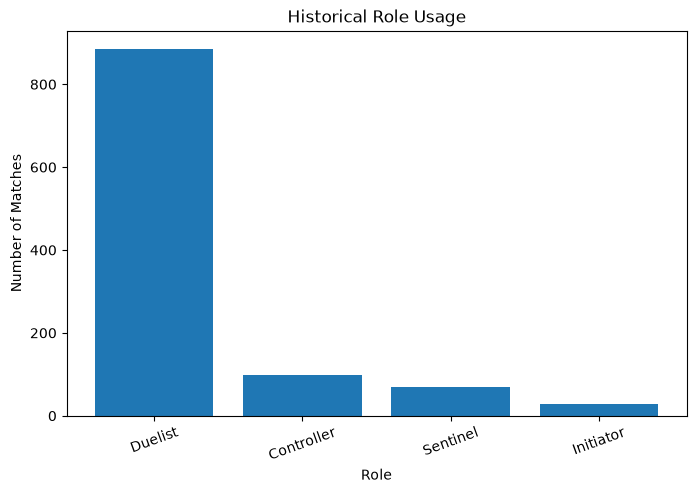

In [54]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    role_distribution["Role"],
    role_distribution["Matches"]
)

plt.title(
    "Historical Role Usage"
)

plt.xlabel(
    "Role"
)

plt.ylabel(
    "Number of Matches"
)

plt.xticks(
    rotation=20
)

plt.show()

In [55]:
# ============================================================
# ROLE PERFORMANCE SUMMARY
# ============================================================

role_summary = (
    df_updated
    .groupby("Role")
    .agg(
        Matches=(
            "Match id",
            "count"
        ),

        Wins=(
            "Result",
            lambda x:
            (x == "Win").sum()
        ),

        Losses=(
            "Result",
            lambda x:
            (x == "Loss").sum()
        ),

        Draws=(
            "Result",
            lambda x:
            (x == "Draw").sum()
        ),

        Average_ACS=(
            "ACS",
            "mean"
        ),

        Median_ACS=(
            "ACS",
            "median"
        ),

        Average_KD=(
            "K/D",
            "mean"
        )
    )
)


role_summary[
    "Win Rate (%)"
] = (
    role_summary["Wins"]
    /
    (
        role_summary["Wins"]
        + role_summary["Losses"]
    )
    * 100
)


role_summary[
    "Usage (%)"
] = (
    role_summary["Matches"]
    / len(df_updated)
    * 100
)


role_summary = (
    role_summary
    .round(2)
    .sort_values(
        "Matches",
        ascending=False
    )
)


role_summary

,Matches,Wins,Losses,Draws,Average_ACS,Median_ACS,Average_KD,Win Rate (%),Usage (%)
Role,,,,,,,,,
Duelist,885,427,438,20,238.43,233.0,1.12,49.36,81.94
Controller,98,41,55,2,218.50,220.0,1.02,42.71,9.07
Sentinel,69,36,31,2,227.26,231.0,1.17,53.73,6.39
Initiator,28,11,16,1,189.25,179.5,0.96,40.74,2.59


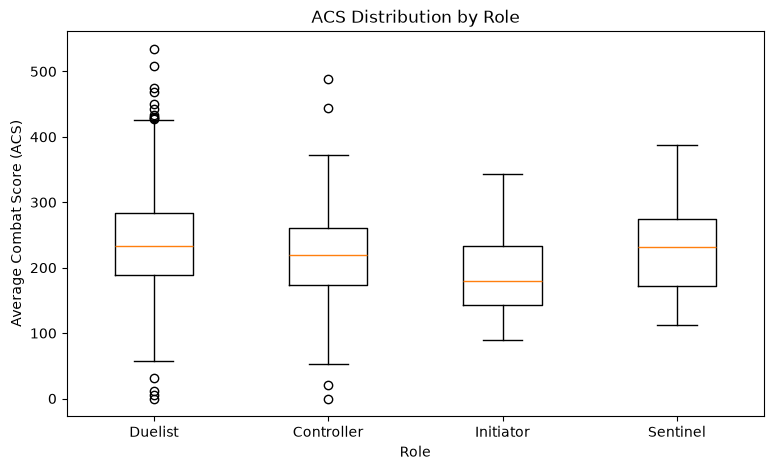

In [56]:
# ============================================================
# ACS DISTRIBUTION BY ROLE
# ============================================================

role_order = [
    "Duelist",
    "Controller",
    "Initiator",
    "Sentinel"
]


acs_by_role = [
    df_updated.loc[
        df_updated["Role"] == role,
        "ACS"
    ].dropna()
    for role in role_order
]


plt.figure(
    figsize=(9, 5)
)

plt.boxplot(
    acs_by_role,
    tick_labels=role_order
)

plt.title(
    "ACS Distribution by Role"
)

plt.xlabel(
    "Role"
)

plt.ylabel(
    "Average Combat Score (ACS)"
)

plt.show()

In [57]:
# ============================================================
# AGENT × ROLE PERFORMANCE
# ============================================================

agent_role_summary = (
    df_updated
    .groupby(
        [
            "Role",
            "Agent"
        ]
    )
    .agg(
        Matches=(
            "Match id",
            "count"
        ),

        Wins=(
            "Result",
            lambda x:
            (x == "Win").sum()
        ),

        Losses=(
            "Result",
            lambda x:
            (x == "Loss").sum()
        ),

        Average_ACS=(
            "ACS",
            "mean"
        ),

        Average_KD=(
            "K/D",
            "mean"
        )
    )
    .reset_index()
)


agent_role_summary[
    "Win Rate (%)"
] = (
    agent_role_summary["Wins"]
    /
    (
        agent_role_summary["Wins"]
        + agent_role_summary["Losses"]
    )
    * 100
)


agent_role_summary = (
    agent_role_summary
    .round(2)
    .sort_values(
        by=[
            "Role",
            "Matches"
        ],
        ascending=[
            True,
            False
        ]
    )
)


agent_role_summary

,Role,Agent,Matches,Wins,Losses,Average_ACS,Average_KD,Win Rate (%)
0,Controller,Astra,45,23,21,225.42,1.15,52.27
4,Controller,Omen,20,7,12,210.65,0.98,36.84
2,Controller,Clove,18,9,9,224.89,0.89,50.00
1,Controller,Brimstone,8,0,8,194.75,0.80,0.00
3,Controller,Miks,6,2,4,216.67,0.91,33.33
5,Controller,Viper,1,0,1,150.00,0.53,0.00
8,Duelist,Neon,739,362,360,239.84,1.13,50.14
11,Duelist,Reyna,55,27,27,230.25,1.16,50.00
7,Duelist,Jett,45,21,23,235.96,1.05,47.73
9,Duelist,Phoenix,16,6,10,207.06,0.98,37.50


### Historical Role-Level Agent Usage

The following table is descriptive only and should not be interpreted as the
final recommendation output.

It shows the two most frequently used historical agents within each role,
together with their historical ACS and win rate.

The final recommendation system will use the trained machine-learning model
rather than selecting agents purely from usage frequency or ACS.


In [58]:
# ============================================================
# MOST-USED AGENTS WITHIN EACH ROLE
# ============================================================

top_used_agents_by_role = (
    agent_role_summary
    .sort_values(
        [
            "Role",
            "Matches"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "Role",
        group_keys=False
    )
    .head(2)
)


top_used_agents_by_role[
    [
        "Role",
        "Agent",
        "Matches",
        "Average_ACS",
        "Win Rate (%)"
    ]
]

,Role,Agent,Matches,Average_ACS,Win Rate (%)
0,Controller,Astra,45,225.42,52.27
4,Controller,Omen,20,210.65,36.84
8,Duelist,Neon,739,239.84,50.14
11,Duelist,Reyna,55,230.25,50.00
14,Initiator,Breach,9,174.67,55.56
16,Initiator,Gekko,9,194.78,12.50
20,Sentinel,Chamber,55,232.58,54.72
24,Sentinel,Sage,7,207.57,42.86


# Initial EDA Findings — Original Dataset

The initial EDA below describes the original dataset. `TRS` was later removed
from the revised role-aware dataset and is not used in the final machine-learning pipeline.


The exploratory data analysis was performed on **1080 VALORANT Competitive
matches from Dev's personal match history**, recorded between **21 June 2025
and 19 September 2026**.

## Dataset Quality

- The dataset contains **1080 matches and 22 original features**.
- No duplicate rows or duplicate Match IDs were detected.
- Match dates were successfully converted into chronological datetime values.
- The dataset contains **25 missing `Win Flag` values**, corresponding to the
  25 drawn matches rather than accidental missing data.
- The K/D column contains one missing value caused by a match with zero deaths,
  where the K/D ratio is mathematically undefined.
- Agent, map, score, and other performance-statistic fields are otherwise
  available for analysis.

Final-score validation currently identifies:

- **926 Regulation matches**
- **113 Overtime matches**
- **23 Overtime Draws**
- **16 Surrendered matches**
- **2 matches requiring manual review**

Surrendered and unusual early-ending matches are retained because they represent
valid Competitive match records rather than automatic data errors.

## Match Outcome Distribution

The 1080 matches consist of:

- **515 Wins**
- **540 Losses**
- **25 Draws**

The overall recorded win rate is approximately **47.69%**.

Wins and losses are reasonably balanced, which is useful for the future binary
classification task.

Draws are retained for descriptive analysis but are excluded from the binary
Win-vs-Loss modelling target.

## Agent Distribution

Dev's match history is strongly dominated by **Neon**.

The most frequently played agents include:

- **Neon: 739 matches**
- **Chamber: 55 matches**
- **Reyna: 55 matches**
- **Astra: 45 matches**
- **Jett: 45 matches**
- **Omen: 20 matches**
- **Clove: 18 matches**

This distribution clearly shows that Dev has substantially more historical
experience with Neon than with any other agent.

Among agents with relatively larger sample sizes:

- Neon has a historical win rate of approximately **49%**
- Chamber has a historical win rate of approximately **53%**
- Reyna has a historical win rate of approximately **49%**
- Astra has a historical win rate of approximately **51%**
- Jett has a historical win rate of approximately **47%**

Raw win rates should not be interpreted without considering sample size.

For example, an agent with only a few matches may show an unusually high win
rate simply because the sample is too small.

This observation supports the use of **agent familiarity and previous match
count** as important features in the final recommendation system.

## Map Distribution

The most frequently played maps are:

- **Haven: 157 matches**
- **Lotus: 125 matches**
- **Split: 105 matches**
- **Ascent: 104 matches**
- **Bind: 94 matches**
- **Breeze: 93 matches**
- **Pearl: 84 matches**
- **Corrode: 84 matches**
- **Sunset: 83 matches**

Among maps with comparatively large sample sizes:

- Haven has a historical win rate of approximately **39%**
- Lotus has a historical win rate of approximately **46%**
- Split has a historical win rate of approximately **47%**
- Ascent has a historical win rate of approximately **45%**
- Bind has a historical win rate of approximately **53%**
- Breeze has a historical win rate of approximately **46%**
- Pearl has a historical win rate of approximately **50%**
- Sunset has a historical win rate of approximately **58%**

These differences indicate that Dev's historical performance varies across maps,
supporting the use of map-specific features in the final recommendation model.

Maps with smaller sample sizes, such as Summit and Icebox, should be interpreted
more cautiously because their win rates may be less stable.

## Agent × Map Patterns

The dataset contains strong evidence that Agent × Map interaction is relevant.

Because Neon is Dev's most frequently played agent, many of the largest
Agent × Map combinations involve Neon.

Some of the largest combinations include:

- **Neon on Haven: 112 matches**, approximately **39% win rate**
- **Neon on Bind: 76 matches**, approximately **54% win rate**
- **Neon on Split: 76 matches**, approximately **45% win rate**
- **Neon on Lotus: 72 matches**, approximately **47% win rate**
- **Neon on Ascent: 65 matches**, approximately **45% win rate**
- **Neon on Pearl: 60 matches**, approximately **55% win rate**
- **Neon on Breeze: 60 matches**, approximately **52% win rate**
- **Neon on Sunset: 55 matches**, approximately **58% win rate**

This shows that the same agent can have noticeably different historical results
depending on the map.

The final recommendation system should therefore evaluate **Agent × Map
performance**, rather than considering agent performance or map performance
independently.

Agent × Map combinations with very small sample sizes must be treated cautiously
because extreme win rates from only a few matches may not be reliable.

## Overall Performance

Across Dev's complete Competitive dataset:

- Overall aggregated K/D is approximately **1.06**
- Mean per-match K/D is approximately **1.11**
- Median per-match K/D is approximately **1.05**
- Average ACS is approximately **234.63**
- Average Headshot Percentage is approximately **26.16%**
- Average DDΔ is approximately **+2.73**

The per-match K/D ranges from:

- Minimum: **0.00**
- Maximum: approximately **4.71**

ACS ranges from **0 to 535**, while DDΔ ranges from **-134 to +195**.

These extreme observations represent unusually strong or weak match performances
and are not removed automatically.

## Performance by Match Outcome — Original Dataset

Clear descriptive differences are observed between wins and losses.

Average performance in wins:

- K/D: approximately **1.33**
- ACS: approximately **255.81**
- DDΔ: approximately **+23.11**
- Kills: approximately **19.12**
- Deaths: approximately **15.26**
- Assists: approximately **3.53**
- TRS: approximately **686.05**

Average performance in losses:

- K/D: approximately **0.90**
- ACS: approximately **213.72**
- DDΔ: approximately **-17.26**
- Kills: approximately **15.66**
- Deaths: approximately **17.34**
- Assists: approximately **3.13**
- TRS: approximately **417.69**

Drawn matches show intermediate or high combat statistics in several metrics,
but they are not treated as either wins or losses in the binary target.

The TRS values above belong to the original dataset only. `TRS` was later
removed from the revised dataset and is not used by the final model.

Overall, stronger combat-performance statistics are associated with wins in this
dataset.

These relationships are descriptive and do not establish causation.

## Updated Role-Aware EDA Findings

The revised Dev dataset retains the same historical match records while
removing `TRS` and adding the new `Role` feature.

The player's role distribution is strongly concentrated toward Duelists.

- Duelist matches represent approximately **82%** of the total match history.
- Controller usage is approximately **9%**.
- Sentinel and Initiator usage are comparatively limited.
- Neon alone represents approximately **68%** of Dev's entire recorded
  Competitive match history.

Average ACS also varies between roles, with Duelist matches showing the
strongest historical ACS profile.

The contrast between this role distribution and the other player's history
demonstrates why the recommendation system should remain player-specific.

Role is determined by the selected agent, while ACS is treated as a historical
performance signal within that role.

The updated feature-engineering pipeline can therefore incorporate role-level
experience, win rate, ACS, usage frequency, and other historical signals before
performing role-aware agent ranking.

## Initial Correlation Findings — Original Dataset

These correlation values were calculated during the initial EDA using the original dataset.
`TRS` was subsequently removed from the revised dataset and is not used in the final
feature-engineering or modelling pipeline.


Among the numerical variables, the strongest positive correlations with
`Win Flag` include:

- TRS: approximately **+0.55**
- K/D: approximately **+0.43**
- DDΔ: approximately **+0.40**
- Kills/Round: approximately **+0.34**
- ACS: approximately **+0.29**
- Kills: approximately **+0.27**

The strongest negative relationships include:

- Deaths: approximately **-0.28**
- Deaths/Round: approximately **-0.43**

These results indicate that higher combat efficiency and stronger overall
performance tend to be associated with winning.

However, these variables describe the current match and therefore cannot be used
directly in a system intended to make recommendations before the match begins.

## Important Machine-Learning Consideration

Variables describing the current match, such as:

- K/D
- ACS
- DDΔ
- Kills
- Deaths
- Assists
- Team Score
- Opponent Score
- Score Margin
- Match End Type

are only known during or after the match has already been played.

Using them directly to predict the outcome of that same match would introduce
**data leakage**.

Instead, the final recommendation system uses historical versions of relevant
variables calculated only from matches played before each target match.

Examples include:

- Recent 5-match win rate
- Recent 10-match win rate
- Recent historical K/D
- Recent historical ACS
- Previous performance with the candidate agent
- Previous performance on the selected map
- Previous Agent × Map performance
- Number of previous matches played with the candidate agent
- Number of previous matches played on the map
- Number of previous matches played with the agent on that specific map
- Agent familiarity based on previous usage and recency
- Previous role match count
- Previous role win rate
- Previous role K/D
- Previous role ACS
- Role usage frequency

## EDA Conclusion

Dev's dataset contains substantially more match history than the smaller
personal dataset used elsewhere in the project and shows a very different
player profile.

Dev predominantly plays **Neon**, while his performance varies across maps and
Agent × Map combinations.

This supports the central idea of the project that agent recommendations should
be **personalized to an individual player's own history**.

The same map may therefore produce different **role-aware recommendations** for
different players.

Following EDA, the revised dataset is cleaned and transformed using
**chronological, leakage-free historical feature engineering** before the
machine-learning models are trained and evaluated.

For a selected map, the final recommendation layer ranks candidate agents within
their respective roles and can return up to **two personalized agents per role**
within a short response time.
